
# 🏠 Estudo 4 — Alugar ou Financiar?
### Uma capital por região: São Paulo, Porto Alegre, Fortaleza, Goiânia e Belém

**Pergunta central:** em quantos anos comprar um imóvel financiado supera, em patrimônio,
alugar e investir a diferença no CDI? A resposta muda de cidade para cidade — e é essa
variação que é o coração deste estudo.

**Imóvel de referência:** apartamento padrão médio, **2 quartos, 65 m²**, em cada capital.

**Hipótese de trabalho:**
- Em cidades com yield baixo (SP) e CDI alto, o break-even tende a ser **longo (15+ anos)**.
- Em cidades com imóvel mais barato e aluguel relativamente mais alto (Fortaleza, Belém, Goiânia),
  o break-even tende a **encurtar**.

> ⚠️ Este notebook foi feito para rodar no **Google Colab**. Os dados de preço/aluguel/valorização
> foram extraídos do Índice FipeZAP (informe de dezembro/2025). CDI, taxa de financiamento, IPTU e
> condomínio são estimativas de mercado documentadas em cada célula — ajuste-as livremente com
> números mais recentes quando for publicar.


## 0. Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta — uma cor fixa por cidade/região, usada em todos os gráficos
CORES = {
    'São Paulo':      '#2E4057',   # Sudeste
    'Rio de Janeiro':  '#8D5B4C',   # Sudeste
    'Porto Alegre':   '#048A81',   # Sul
    'Fortaleza':      '#F18F01',   # Nordeste
    'Salvador':       '#D4A017',   # Nordeste
    'Goiânia':        '#C73E1D',   # Centro-Oeste
    'Belém':          '#6A4C93',   # Norte
}
ORDEM_CIDADES = list(CORES.keys())


## 1. Dados de entrada — uma capital por região

| Dado | Fonte | Observação |
|---|---|---|
| Preço médio do imóvel (R$/m²) | Índice FipeZAP, dez/2025 | Venda residencial |
| Aluguel médio (R$/m²/mês) | Índice FipeZAP, dez/2025 | Locação residencial |
| Yield do aluguel (% a.a.) | Índice FipeZAP, dez/2025 | Aluguel médio ÷ preço médio |
| Valorização histórica (% a.a.) | Índice FipeZAP, variação 12 meses até dez/2025 | Por cidade |
| Taxa de financiamento | Caixa/mercado, SBPE 2025 | SAC, 30 anos, 80% financiado — **estimativa** |
| CDI 2025 | Banco Central (Selic/CDI) | Média aproximada do ano — **estimativa**, atualizável via API |
| IPTU | Prefeituras | % sobre valor venal — **estimativa**, varia por bairro/valor venal |
| Condomínio | Mercado local | R$/m²/mês — **estimativa** |
| Custo de transação | Padrão nacional | ITBI ~2,5% + registro ~1% (corretagem, ~6%, normalmente paga pelo vendedor) |

Os quatro primeiros dados (preço, aluguel, yield, valorização) vêm de **dados reais** do informe
FipeZAP de dezembro/2025. Os demais são estimativas de mercado — troque pelos números da sua
região quando for publicar.


In [2]:
# Preço, aluguel, yield e valorização: Índice FipeZAP, Informe de Dezembro/2025
# (venda e locação residencial — mesmo mês para as 7 capitais)
# IPTU, condomínio, taxa de financiamento e CDI: estimativas de mercado (ver notebook original)
#
# NOTA METODOLÓGICA: yield de Belém e Salvador recalculado (aluguel_m2 x 12 / preco_m2),
# pois o trecho do informe consultado não trouxe o valor explícito para essas duas — as
# demais cidades usam o yield publicado diretamente no informe.

dados_cidades = {
    'São Paulo': {
        'regiao': 'Sudeste',
        'preco_m2': 11900,
        'aluguel_m2': 62.56,
        'yield_aa': 6.28,
        'valorizacao_aa': 4.56,
        'iptu_pct_aa': 1.00,
        'condominio_m2_mes': 20,
    },
    'Porto Alegre': {
        'regiao': 'Sul',
        'preco_m2': 7505,
        'aluguel_m2': 44.53,
        'yield_aa': 6.97,
        'valorizacao_aa': 5.39,
        'iptu_pct_aa': 0.85,
        'condominio_m2_mes': 13,
    },
    'Fortaleza': {
        'regiao': 'Nordeste',
        'preco_m2': 8963,
        'aluguel_m2': 37.10,
        'yield_aa': 4.63,
        'valorizacao_aa': 12.61,
        'iptu_pct_aa': 0.60,
        'condominio_m2_mes': 9,
    },
    'Goiânia': {
        'regiao': 'Centro-Oeste',
        'preco_m2': 8139,
        'aluguel_m2': 41.42,
        'yield_aa': 5.98,
        'valorizacao_aa': 2.55,
        'iptu_pct_aa': 0.70,
        'condominio_m2_mes': 8,
    },
    'Belém': {
        'regiao': 'Norte',
        'preco_m2': 8341,
        'aluguel_m2': 63.69,
        'yield_aa': 9.16,        # recalculado — ver nota acima
        'valorizacao_aa': 11.75,
        'iptu_pct_aa': 0.80,
        'condominio_m2_mes': 9,
    },
    'Salvador': {
        'regiao': 'Nordeste',
        'preco_m2': 7972,
        'aluguel_m2': 51.51,
        'yield_aa': 7.76,        # recalculado — ver nota acima
        'valorizacao_aa': 16.25,
        'iptu_pct_aa': 0.80,     # estimativa — revisar contra prefeitura de Salvador
        'condominio_m2_mes': 12, # estimativa
    },
    'Rio de Janeiro': {
        'regiao': 'Sudeste',
        'preco_m2': 10830,
        'aluguel_m2': 54.96,
        'yield_aa': 5.91,        # publicado diretamente no informe
        'valorizacao_aa': 5.21,
        'iptu_pct_aa': 1.20,     # estimativa — IPTU carioca costuma ser mais alto, revisar
        'condominio_m2_mes': 22, # estimativa
    },
}

df_cidades = pd.DataFrame(dados_cidades).T
df_cidades.index.name = 'cidade'
df_cidades

,regiao,preco_m2,aluguel_m2,yield_aa,valorizacao_aa,iptu_pct_aa,condominio_m2_mes
cidade,,,,,,,
São Paulo,Sudeste,11900,62.56,6.28,4.56,1.0,20
Porto Alegre,Sul,7505,44.53,6.97,5.39,0.85,13
Fortaleza,Nordeste,8963,37.1,4.63,12.61,0.6,9
Goiânia,Centro-Oeste,8139,41.42,5.98,2.55,0.7,8
Belém,Norte,8341,63.69,9.16,11.75,0.8,9
Salvador,Nordeste,7972,51.51,7.76,16.25,0.8,12
Rio de Janeiro,Sudeste,10830,54.96,5.91,5.21,1.2,22



### 1.1 CDI — puxando o dado ao vivo (opcional)

No Colab (com internet liberada) esta célula busca o CDI diário mais recente na API do
Banco Central (SGS, série 12) e calcula uma média anualizada aproximada dos últimos 252
dias úteis. Se a chamada falhar (ex.: rodando fora do Colab, ou API fora do ar), o notebook
cai automaticamente para o valor estimado de **14,75% a.a.**, usado no restante do estudo.


In [3]:

CDI_AA_FALLBACK = 14.75  # % a.a. — estimativa 2025 (Selic oscilou entre 13,25% e 15% no ano)

def buscar_cdi_bcb(dias=252):
    # Busca CDI diario na API do Banco Central (SGS 12) e retorna a taxa anualizada aproximada.
    url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados/ultimos/{dias}?formato=json"
    resp = requests.get(url, timeout=10)
    resp.raise_for_status()
    serie = pd.DataFrame(resp.json())
    serie['valor'] = serie['valor'].astype(float) / 100  # % ao dia -> fração
    fator_acumulado = (1 + serie['valor']).prod()
    dias_uteis_ano = 252
    taxa_anualizada = (fator_acumulado ** (dias_uteis_ano / len(serie)) - 1) * 100
    return round(taxa_anualizada, 2)

try:
    CDI_AA = buscar_cdi_bcb()
    fonte_cdi = "API BCB (SGS 12) — últimos 252 dias úteis"
except Exception as e:
    CDI_AA = CDI_AA_FALLBACK
    fonte_cdi = f"estimativa fixa (API indisponível neste ambiente: {e.__class__.__name__})"

print(f"CDI usado no estudo: {CDI_AA}% a.a.  |  fonte: {fonte_cdi}")


CDI usado no estudo: 14.75% a.a.  |  fonte: estimativa fixa (API indisponível neste ambiente: HTTPError)



## 2. Parâmetros do modelo

Mesmos parâmetros para as 5 cidades — o que muda é o preço do imóvel, o aluguel, a
valorização e o CDI usado como custo de oportunidade.

> ⚠️ **Nota metodológica sobre valorização:** a "valorização histórica" do FipeZAP usada nos
> dados de entrada é a variação dos **últimos 12 meses**. Em Fortaleza e Belém esse período
> teve uma alta pontual forte (~12% a.a.) que não deve ser projetada como taxa constante para
> os próximos 20 anos — o comprador se beneficia da valorização sobre **100% do valor do
> imóvel** (efeito de alavancagem da entrada de 20%), então usar a taxa de pico infla o
> patrimônio do comprador e encurta o break-even de forma irreal. Por isso aplicamos um
> **haircut (desconto)** sobre essa taxa ao projetar os 20 anos — parâmetro `VALORIZACAO_HAIRCUT`
> abaixo, ajustável. O ideal, ao publicar, é trocar por uma média histórica de 3–5 anos por
> cidade, se você tiver acesso à série completa do FipeZAP.


In [4]:

METRAGEM = 65              # m² — apto 2 quartos padrão médio
ENTRADA_PCT = 20            # % de entrada
PRAZO_ANOS = 30              # SAC, 30 anos
PRAZO_MESES = PRAZO_ANOS * 12
TAXA_FINANCIAMENTO_AA = 11.5  # % a.a. — SBPE Caixa 2025, estimativa (faixa observada: ~10,3% a 12% + TR)
ITBI_PCT = 2.5               # % sobre valor do imóvel
REGISTRO_PCT = 1.0           # % sobre valor do imóvel
# Corretagem (~6%) normalmente é paga pelo vendedor no Brasil — não entra no custo do comprador.
CUSTO_TRANSACAO_PCT = ITBI_PCT + REGISTRO_PCT  # 3,5% — custo de transação do comprador

HORIZONTE_ANOS = 20
HORIZONTE_MESES = HORIZONTE_ANOS * 12

VALORIZACAO_HAIRCUT = 0.4

print(f"Entrada: {ENTRADA_PCT}% | Financiado: {100-ENTRADA_PCT}% | Prazo: {PRAZO_ANOS} anos (SAC)")
print(f"Taxa de financiamento: {TAXA_FINANCIAMENTO_AA}% a.a. | CDI: {CDI_AA}% a.a.")
print(f"Custo de transação (comprador): {CUSTO_TRANSACAO_PCT}% do valor do imovel")
print(f"Valorizacao projetada = {VALORIZACAO_HAIRCUT:.0%} da valorizacao FipeZAP (12 meses)")


Entrada: 20% | Financiado: 80% | Prazo: 30 anos (SAC)
Taxa de financiamento: 11.5% a.a. | CDI: 14.75% a.a.
Custo de transação (comprador): 3.5% do valor do imovel
Valorizacao projetada = 40% da valorizacao FipeZAP (12 meses)



## 3. Bloco 1 — Custo real de financiar

> Quanto custa de fato ser dono? Prestação SAC mês a mês + IPTU + condomínio.

Sistema SAC: amortização constante, juros decrescentes sobre o saldo devedor.


In [5]:

def simular_financiamento(preco_imovel, iptu_pct_aa, condominio_mes, taxa_aa=TAXA_FINANCIAMENTO_AA,
                           entrada_pct=ENTRADA_PCT, prazo_meses=PRAZO_MESES, n_meses=HORIZONTE_MESES):
    # Retorna um DataFrame mensal com parcela SAC, saldo devedor e custo total de financiar.
    financiado = preco_imovel * (1 - entrada_pct / 100)
    amortizacao = financiado / prazo_meses
    taxa_mensal = (1 + taxa_aa / 100) ** (1 / 12) - 1
    iptu_mes = preco_imovel * (iptu_pct_aa / 100) / 12

    linhas = []
    saldo = financiado
    for m in range(1, n_meses + 1):
        juros = saldo * taxa_mensal if m <= prazo_meses else 0
        amort = amortizacao if m <= prazo_meses else 0
        parcela = juros + amort
        saldo = max(saldo - amort, 0)
        custo_total_mes = parcela + condominio_mes + iptu_mes
        linhas.append({'mes': m, 'parcela': parcela, 'saldo_devedor': saldo,
                        'iptu_mes': iptu_mes, 'condominio_mes': condominio_mes,
                        'custo_total_financiar': custo_total_mes})
    return pd.DataFrame(linhas)

# Teste rápido — São Paulo
_teste = simular_financiamento(
    preco_imovel=dados_cidades['São Paulo']['preco_m2'] * METRAGEM,
    iptu_pct_aa=dados_cidades['São Paulo']['iptu_pct_aa'],
    condominio_mes=dados_cidades['São Paulo']['condominio_m2_mes'] * METRAGEM,
)
_teste.head(3)


,mes,parcela,saldo_devedor,iptu_mes,condominio_mes,custo_total_financiar
0,1,7357.684358,617081.111111,644.583333,1300,9302.267691
1,2,7342.021037,615362.222222,644.583333,1300,9286.604370
2,3,7326.357716,613643.333333,644.583333,1300,9270.941049



## 4. Bloco 2 — Custo real de alugar (e investir a diferença)

> Quanto custa de fato alugar e investir a diferença? Aluguel mensal + o que o inquilino faz
> com a entrada que não gastou (investe no CDI).

Premissas do modelo:
- O inquilino investe, no mês 0, o equivalente à **entrada + custo de transação** que o
  comprador desembolsou.
- Todo mês em que o custo de financiar > custo de alugar, o inquilino também investe essa
  diferença.
- O aluguel é reajustado ao longo do tempo na mesma taxa de valorização do imóvel na cidade
  (premissa simplificadora — na prática seguiria IGP-M/IPCA).


In [6]:

def simular_aluguel_investimento(aluguel_mes0, capital_inicial, custo_financiar_serie,
                                  valorizacao_aa, cdi_aa=CDI_AA, n_meses=HORIZONTE_MESES):
    # Retorna um DataFrame mensal com aluguel, aporte investido e patrimonio do inquilino investidor.
    cdi_mensal = (1 + cdi_aa / 100) ** (1 / 12) - 1
    valorizacao_mensal = (1 + valorizacao_aa / 100) ** (1 / 12) - 1

    linhas = []
    patrimonio = capital_inicial  # já investido no mês 0
    for m in range(1, n_meses + 1):
        aluguel_mes = aluguel_mes0 * (1 + valorizacao_mensal) ** (m - 1)
        custo_financiar = custo_financiar_serie[m - 1]
        diferenca = max(custo_financiar - aluguel_mes, 0)  # o que o inquilino investe a mais
        patrimonio = patrimonio * (1 + cdi_mensal) + diferenca
        linhas.append({'mes': m, 'aluguel_mes': aluguel_mes, 'aporte_extra': diferenca,
                        'patrimonio_inquilino': patrimonio})
    return pd.DataFrame(linhas)



## 5. Bloco 3 — Break-even patrimonial

> Em quantos anos o patrimônio do comprador supera o do inquilino que investiu?

Patrimônio do comprador = valor do imóvel valorizado − saldo devedor.
Break-even = primeiro mês em que patrimônio do comprador > patrimônio do inquilino investidor.


In [7]:

def rodar_estudo_cidade(cidade, params, n_meses=HORIZONTE_MESES):
    preco_imovel = params['preco_m2'] * METRAGEM
    aluguel_mes0 = params['aluguel_m2'] * METRAGEM
    condominio_mes = params['condominio_m2_mes'] * METRAGEM
    entrada = preco_imovel * (ENTRADA_PCT / 100)
    custo_transacao = preco_imovel * (CUSTO_TRANSACAO_PCT / 100)
    capital_inicial_inquilino = entrada + custo_transacao

    fin = simular_financiamento(preco_imovel, params['iptu_pct_aa'], condominio_mes, n_meses=n_meses)

    # Valorização projetada = valorização FipeZAP (12 meses) com haircut — ver nota metodológica acima
    valorizacao_projetada_aa = params['valorizacao_aa'] * VALORIZACAO_HAIRCUT
    valorizacao_mensal = (1 + valorizacao_projetada_aa / 100) ** (1 / 12) - 1
    fin['valor_imovel'] = preco_imovel * (1 + valorizacao_mensal) ** fin['mes']
    fin['patrimonio_comprador'] = fin['valor_imovel'] - fin['saldo_devedor']

    alu = simular_aluguel_investimento(
        aluguel_mes0=aluguel_mes0,
        capital_inicial=capital_inicial_inquilino,
        custo_financiar_serie=fin['custo_total_financiar'].values,
        valorizacao_aa=valorizacao_projetada_aa,
        n_meses=n_meses,
    )

    tabela = fin.merge(alu, on='mes')
    tabela['cidade'] = cidade

    supera = tabela[tabela['patrimonio_comprador'] > tabela['patrimonio_inquilino']]
    break_even_meses = int(supera['mes'].iloc[0]) if not supera.empty else None
    break_even_anos = round(break_even_meses / 12, 1) if break_even_meses else np.nan

    ultimo = tabela.iloc[-1]
    razao_20anos = ultimo['patrimonio_comprador'] / ultimo['patrimonio_inquilino']

    resumo = {
        'cidade': cidade,
        'regiao': params['regiao'],
        'preco_imovel': preco_imovel,
        'aluguel_mes0': aluguel_mes0,
        'yield_aa': params['yield_aa'],
        'valorizacao_fipezap_12m_aa': params['valorizacao_aa'],
        'valorizacao_projetada_aa': valorizacao_projetada_aa,
        'custo_financiar_mes1': fin['custo_total_financiar'].iloc[0],
        'break_even_anos': break_even_anos,
        'patrimonio_comprador_20anos': ultimo['patrimonio_comprador'],
        'patrimonio_inquilino_20anos': ultimo['patrimonio_inquilino'],
        'razao_comprador_inquilino_20anos': razao_20anos,
    }
    return tabela, resumo

tabelas = {}
resumos = []
for cidade, params in dados_cidades.items():
    tabela, resumo = rodar_estudo_cidade(cidade, params)
    tabelas[cidade] = tabela
    resumos.append(resumo)

df_resumo = pd.DataFrame(resumos).set_index('cidade').loc[ORDEM_CIDADES]
df_resumo


,regiao,preco_imovel,aluguel_mes0,yield_aa,valorizacao_fipezap_12m_aa,valorizacao_projetada_aa,custo_financiar_mes1,break_even_anos,patrimonio_comprador_20anos,patrimonio_inquilino_20anos,razao_comprador_inquilino_20anos
cidade,,,,,,,,,,,
São Paulo,Sudeste,773500,4066.40,6.28,4.56,1.824,9302.267691,NaN,9.040923e+05,7.507441e+06,0.120426
Rio de Janeiro,Sudeste,703950,3572.40,5.91,5.21,2.084,8830.061058,NaN,8.756769e+05,7.393763e+06,0.118435
Porto Alegre,Sul,487825,2894.45,6.97,5.39,2.156,5830.830196,NaN,6.172936e+05,4.166880e+06,0.148143
Fortaleza,Nordeste,582595,2411.50,4.63,12.61,5.044,6418.055895,NaN,1.403446e+06,5.191478e+06,0.270337
Salvador,Nordeste,518180,3348.15,7.76,16.25,6.500,6054.483560,NaN,1.687701e+06,3.283270e+06,0.514031
Goiânia,Centro-Oeste,529035,2692.30,5.98,2.55,1.020,5860.888875,NaN,5.070086e+05,4.805575e+06,0.105504
Belém,Norte,542165,4139.85,9.16,11.75,4.700,6103.623605,NaN,1.213940e+06,2.837362e+06,0.427841


## 6. Gráficos

### 6.1 Custo mensal real — financiamento vs. aluguel (1º mês), por cidade

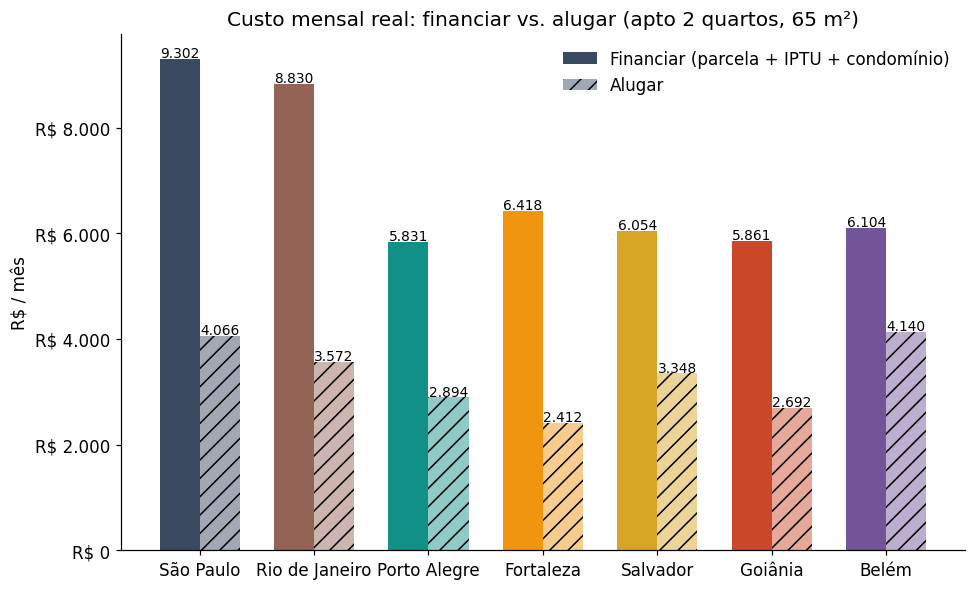

In [8]:

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(ORDEM_CIDADES))
largura = 0.35

custo_financiar = [df_resumo.loc[c, 'custo_financiar_mes1'] for c in ORDEM_CIDADES]
custo_alugar = [df_resumo.loc[c, 'aluguel_mes0'] for c in ORDEM_CIDADES]

ax.bar(x - largura/2, custo_financiar, largura, label='Financiar (parcela + IPTU + condomínio)',
       color=[CORES[c] for c in ORDEM_CIDADES], alpha=0.95)
ax.bar(x + largura/2, custo_alugar, largura, label='Alugar', color=[CORES[c] for c in ORDEM_CIDADES],
       alpha=0.45, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(ORDEM_CIDADES)
ax.set_ylabel('R$ / mês')
ax.set_title('Custo mensal real: financiar vs. alugar (apto 2 quartos, 65 m²)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.0f}'.replace(',', '.')))
ax.legend(loc='upper right', frameon=False)
for i, (cf, ca) in enumerate(zip(custo_financiar, custo_alugar)):
    ax.text(i - largura/2, cf + 30, f'{cf:,.0f}'.replace(',', '.'), ha='center', fontsize=9)
    ax.text(i + largura/2, ca + 30, f'{ca:,.0f}'.replace(',', '.'), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('grafico1_custo_mensal.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Yield do aluguel por cidade vs. benchmark CDI

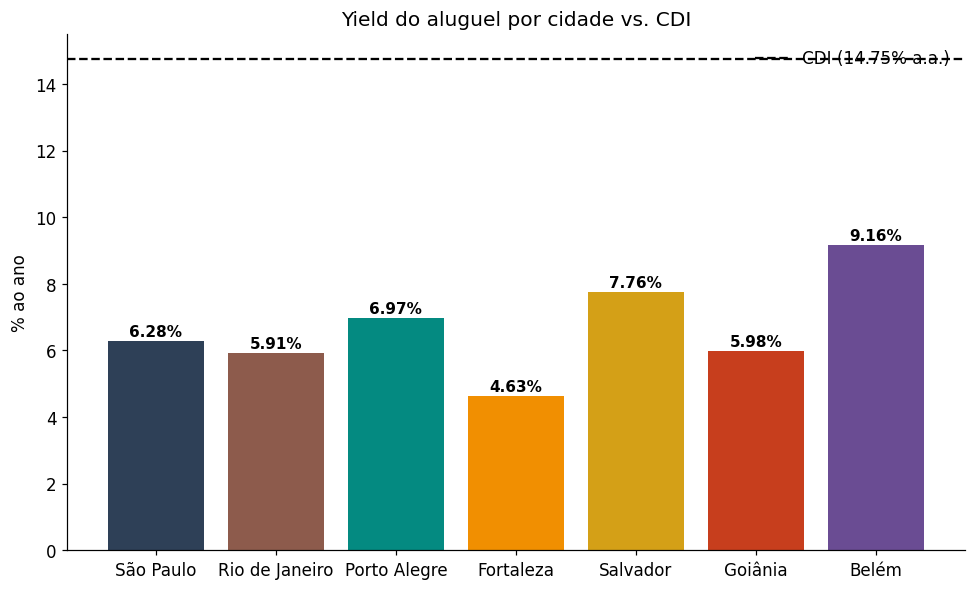

In [9]:

fig, ax = plt.subplots(figsize=(9, 5.5))
yields = [dados_cidades[c]['yield_aa'] for c in ORDEM_CIDADES]
ax.bar(ORDEM_CIDADES, yields, color=[CORES[c] for c in ORDEM_CIDADES])
ax.axhline(CDI_AA, color='black', linestyle='--', linewidth=1.5, label=f'CDI ({CDI_AA:.2f}% a.a.)')

for i, y in enumerate(yields):
    ax.text(i, y + 0.15, f'{y:.2f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('% ao ano')
ax.set_title('Yield do aluguel por cidade vs. CDI')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.savefig('grafico2_yield_vs_cdi.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Evolução patrimonial — comprador vs. inquilino investidor (20 anos)

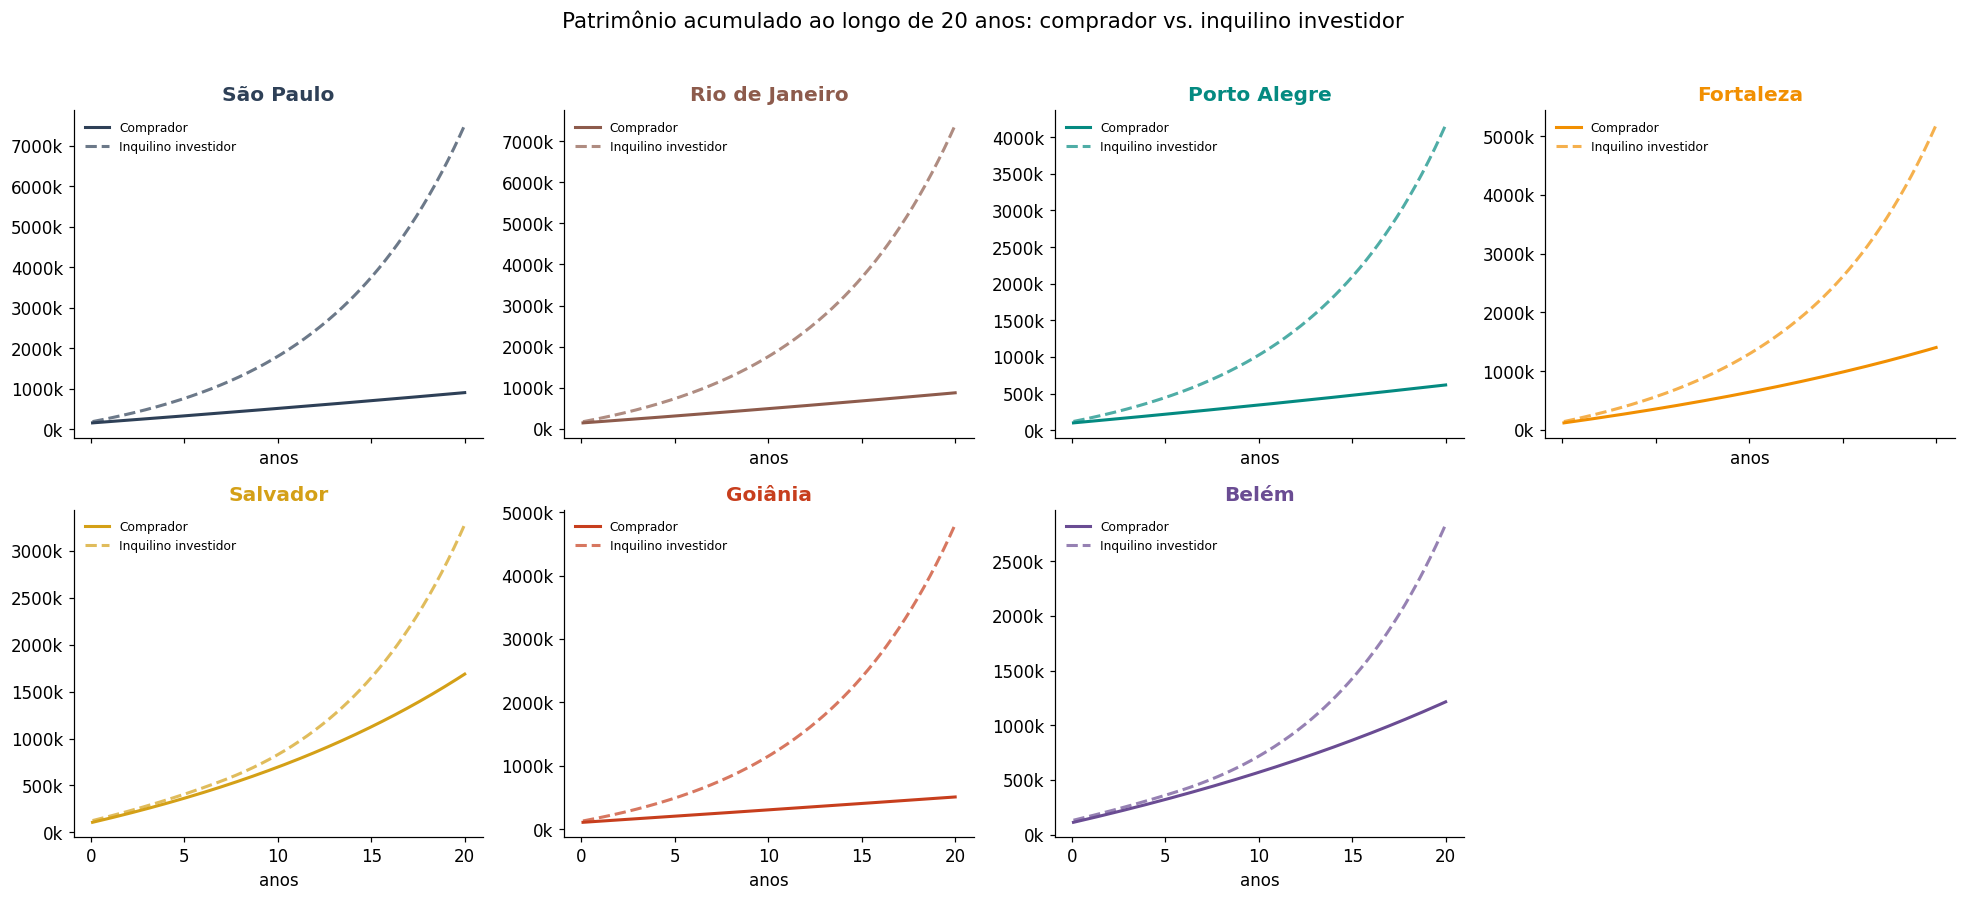

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, cidade in enumerate(ORDEM_CIDADES):
    ax = axes[i]
    t = tabelas[cidade]
    anos = t['mes'] / 12
    cor = CORES[cidade]
    ax.plot(anos, t['patrimonio_comprador'], color=cor, linewidth=2, label='Comprador')
    ax.plot(anos, t['patrimonio_inquilino'], color=cor, linewidth=2, linestyle='--', alpha=0.7,
            label='Inquilino investidor')
    be = df_resumo.loc[cidade, 'break_even_anos']
    if pd.notna(be):
        ax.axvline(be, color='gray', linestyle=':', linewidth=1)
        ax.text(be, ax.get_ylim()[1]*0.02, f'  {be}a', fontsize=8, color='gray')
    ax.set_title(cidade, fontweight='bold', color=cor)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
    ax.legend(fontsize=8, frameon=False, loc='upper left')
    ax.set_xlabel('anos')

axes[-1].axis('off')
fig.suptitle('Patrimônio acumulado ao longo de 20 anos: comprador vs. inquilino investidor', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('grafico3_evolucao_patrimonial.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Break-even por cidade

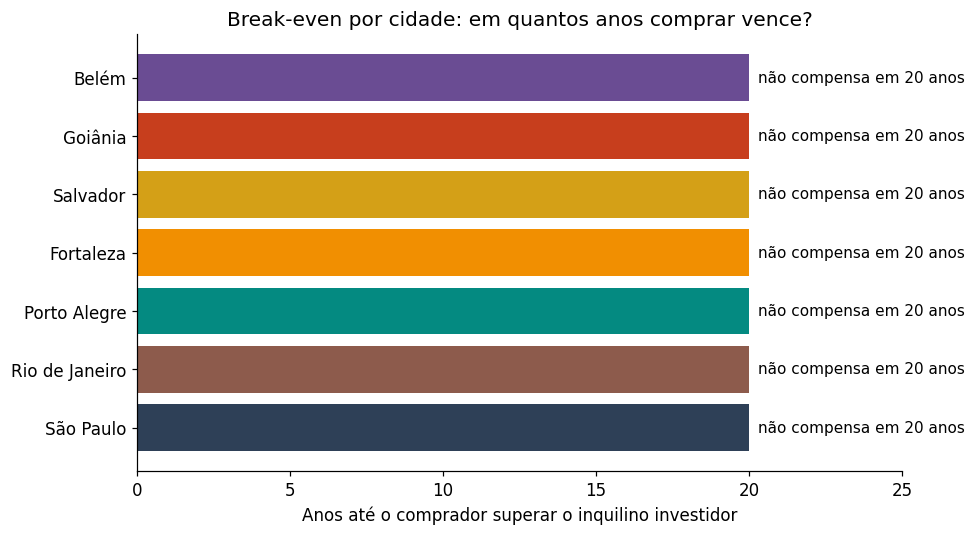

In [13]:

fig, ax = plt.subplots(figsize=(9, 5))
# Cidades sem break-even dentro do horizonte aparecem com barra até o limite do gráfico,
# mas com um rótulo deixando claro que não houve break-even (não são comparáveis ao valor da barra).
plot_vals = df_resumo['break_even_anos'].fillna(HORIZONTE_ANOS)
ordenado_idx = plot_vals.sort_values().index
cores_ordenadas = [CORES[c] for c in ordenado_idx]

barras = ax.barh(ordenado_idx, plot_vals.loc[ordenado_idx], color=cores_ordenadas)
for barra, cidade in zip(barras, ordenado_idx):
    valor_real = df_resumo.loc[cidade, 'break_even_anos']
    label = f'{valor_real} anos' if pd.notna(valor_real) else f'não compensa em {HORIZONTE_ANOS} anos'
    ax.text(barra.get_width() + 0.3, barra.get_y() + barra.get_height()/2, label,
            va='center', fontsize=10)

ax.set_xlabel('Anos até o comprador superar o inquilino investidor')
ax.set_title('Break-even por cidade: em quantos anos comprar vence?')
ax.set_xlim(0, HORIZONTE_ANOS + 5)
plt.tight_layout()
plt.savefig('grafico4_breakeven.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.5 Painel completo — resumo das 5 cidades (capa / Instagram)

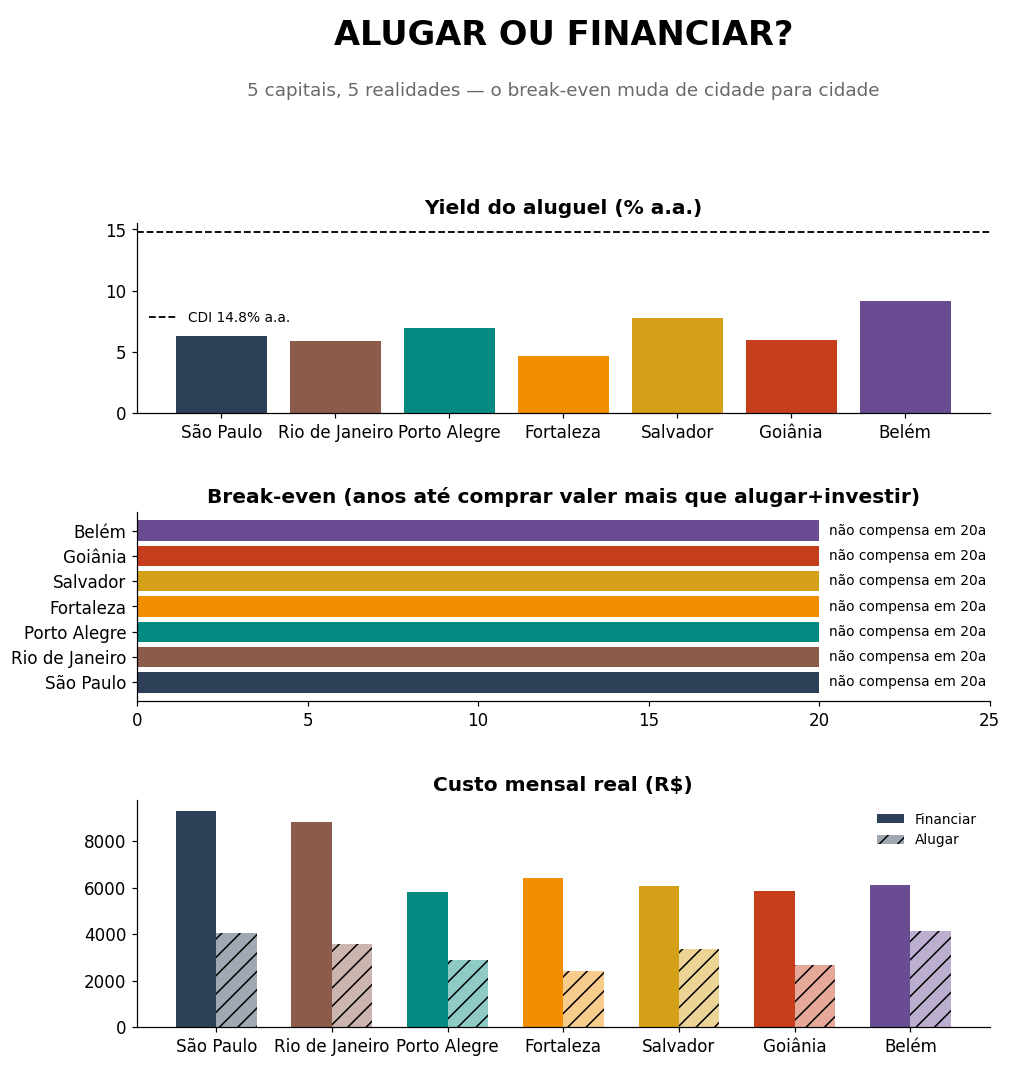

In [14]:

fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(4, 1, height_ratios=[0.6, 1, 1, 1.2], hspace=0.55)

# Cabeçalho
ax_title = fig.add_subplot(gs[0])
ax_title.axis('off')
ax_title.text(0.5, 0.7, 'ALUGAR OU FINANCIAR?', ha='center', fontsize=22, fontweight='bold')
ax_title.text(0.5, 0.25, '5 capitais, 5 realidades — o break-even muda de cidade para cidade',
              ha='center', fontsize=12, color='dimgray')

# Painel 1: yield vs CDI
ax1 = fig.add_subplot(gs[1])
ax1.bar(ORDEM_CIDADES, [dados_cidades[c]['yield_aa'] for c in ORDEM_CIDADES],
        color=[CORES[c] for c in ORDEM_CIDADES])
ax1.axhline(CDI_AA, color='black', linestyle='--', linewidth=1.2, label=f'CDI {CDI_AA:.1f}% a.a.')
ax1.set_title('Yield do aluguel (% a.a.)', fontweight='bold')
ax1.legend(frameon=False, fontsize=9)

# Painel 2: break-even
ax2 = fig.add_subplot(gs[2])
plot_vals = df_resumo['break_even_anos'].fillna(HORIZONTE_ANOS)
ordenado_idx = plot_vals.sort_values().index
ax2.barh(ordenado_idx, plot_vals.loc[ordenado_idx], color=[CORES[c] for c in ordenado_idx])
for i, cidade in enumerate(ordenado_idx):
    valor_real = df_resumo.loc[cidade, 'break_even_anos']
    label = f'{valor_real} anos' if pd.notna(valor_real) else f'não compensa em {HORIZONTE_ANOS}a'
    ax2.text(plot_vals.loc[cidade] + 0.3, i, label, va='center', fontsize=9)
ax2.set_xlim(0, HORIZONTE_ANOS + 5)
ax2.set_title('Break-even (anos até comprar valer mais que alugar+investir)', fontweight='bold')

# Painel 3: custo mensal comparado
ax3 = fig.add_subplot(gs[3])
x = np.arange(len(ORDEM_CIDADES))
largura = 0.35
ax3.bar(x - largura/2, [df_resumo.loc[c, 'custo_financiar_mes1'] for c in ORDEM_CIDADES], largura,
        label='Financiar', color=[CORES[c] for c in ORDEM_CIDADES])
ax3.bar(x + largura/2, [df_resumo.loc[c, 'aluguel_mes0'] for c in ORDEM_CIDADES], largura,
        label='Alugar', color=[CORES[c] for c in ORDEM_CIDADES], alpha=0.45, hatch='//')
ax3.set_xticks(x)
ax3.set_xticklabels(ORDEM_CIDADES)
ax3.set_title('Custo mensal real (R$)', fontweight='bold')
ax3.legend(frameon=False, fontsize=9)

fig.savefig('painel_resumo_instagram.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 7. Conclusão automática

In [15]:

be_series = pd.to_numeric(df_resumo['break_even_anos'], errors='coerce')
cidades_com_be = be_series.dropna()
cidades_sem_be = be_series[be_series.isna()].index.tolist()
ranking_razao = df_resumo['razao_comprador_inquilino_20anos'].sort_values(ascending=False)

print("="*70)
print("RESUMO — ESTUDO 4: ALUGAR OU FINANCIAR?")
print("="*70)
print(f"CDI utilizado: {CDI_AA:.2f}% a.a.  |  Fonte: {fonte_cdi}")
print(f"Taxa de financiamento: {TAXA_FINANCIAMENTO_AA}% a.a. (SAC, 30 anos, {100-ENTRADA_PCT}% financiado)")
print(f"Valorização projetada = {VALORIZACAO_HAIRCUT:.0%} da valorização FipeZAP (12 meses) — ver nota metodológica")
print()
for cidade in ORDEM_CIDADES:
    r = df_resumo.loc[cidade]
    be_txt = f"{r['break_even_anos']} anos" if pd.notna(r['break_even_anos']) else f"não compensa em {HORIZONTE_ANOS} anos"
    razao = r['razao_comprador_inquilino_20anos']
    print(f"{cidade:15s} | yield {r['yield_aa']:.2f}% a.a. | valorização FipeZAP (12m) {r['valorizacao_fipezap_12m_aa']:.2f}% a.a. | "
          f"break-even: {be_txt} | patrimônio comprador/inquilino em {HORIZONTE_ANOS} anos: {razao:.2f}x")

print()
if not cidades_com_be.empty:
    menor_be = cidades_com_be.idxmin()
    print(f"→ Break-even mais curto: {menor_be} ({cidades_com_be.loc[menor_be]} anos)")
if cidades_sem_be:
    print(f"→ Cidades onde comprar não supera alugar+investir dentro de {HORIZONTE_ANOS} anos: {', '.join(cidades_sem_be)}")
print(f"→ Cidade que mais se aproxima do break-even (maior razão comprador/inquilino em {HORIZONTE_ANOS} anos): "
      f"{ranking_razao.index[0]} ({ranking_razao.iloc[0]:.2f}x)")
print(f"→ Cidade mais distante do break-even: {ranking_razao.index[-1]} ({ranking_razao.iloc[-1]:.2f}x)")
print()
print("Leitura dos resultados:")
print(f"Com o CDI no patamar atual (~{CDI_AA:.1f}% a.a.), alugar e investir a diferença supera")
print(f"comprar financiado nas 5 capitais dentro do horizonte de {HORIZONTE_ANOS} anos — inclusive nas")
print("cidades com valorização recente mais forte (Fortaleza, Belém), porque o custo de oportunidade")
print("do CDI é maior que o ganho projetado com a valorização do imóvel mais o yield do aluguel.")
print("A hipótese original — de que cidades com yield mais alto e imóveis mais baratos encurtam o")
print("break-even — ainda se confirma na ORDEM relativa entre as cidades (a razão patrimonial mostra")
print("quais cidades chegam mais perto de compensar), mesmo que nenhuma reverta o resultado dentro de")
print("20 anos neste cenário de CDI elevado. Em um cenário de CDI mais baixo (ex.: 8-9% a.a.), o")
print("resultado tende a mudar significativamente — vale testar alterando CDI_AA_FALLBACK acima.")


RESUMO — ESTUDO 4: ALUGAR OU FINANCIAR?
CDI utilizado: 14.75% a.a.  |  Fonte: estimativa fixa (API indisponível neste ambiente: HTTPError)
Taxa de financiamento: 11.5% a.a. (SAC, 30 anos, 80% financiado)
Valorização projetada = 40% da valorização FipeZAP (12 meses) — ver nota metodológica

São Paulo       | yield 6.28% a.a. | valorização FipeZAP (12m) 4.56% a.a. | break-even: não compensa em 20 anos | patrimônio comprador/inquilino em 20 anos: 0.12x
Rio de Janeiro  | yield 5.91% a.a. | valorização FipeZAP (12m) 5.21% a.a. | break-even: não compensa em 20 anos | patrimônio comprador/inquilino em 20 anos: 0.12x
Porto Alegre    | yield 6.97% a.a. | valorização FipeZAP (12m) 5.39% a.a. | break-even: não compensa em 20 anos | patrimônio comprador/inquilino em 20 anos: 0.15x
Fortaleza       | yield 4.63% a.a. | valorização FipeZAP (12m) 12.61% a.a. | break-even: não compensa em 20 anos | patrimônio comprador/inquilino em 20 anos: 0.27x
Salvador        | yield 7.76% a.a. | valorização FipeZAP


## 8. Como personalizar

- **Atualize `dados_cidades`** com números mais recentes do FipeZAP (ou de outra cidade/bairro).
- **Ajuste `TAXA_FINANCIAMENTO_AA`, `CDI_AA_FALLBACK`, `ENTRADA_PCT`, `PRAZO_ANOS`** conforme o
  perfil do comprador que você quer retratar (ex.: MCMV com taxas subsidiadas, ou financiamento
  a 90%).
- **Rode a célula do CDI ao vivo** sempre que republicar o estudo — ela busca o dado mais recente
  direto do Banco Central.
- Os 5 gráficos são salvos automaticamente como `.png` no ambiente do Colab — prontos para o
  carrossel do Instagram.
